# NITID 1º tutorial: inferences pre-trained Models

Nitid it is an object detector that simplifies the use of the RETR open source family and that you can easily use for whatever you want (without a restrictive license)

This notebook walks through the basic nitid workflow:
1. Set up the project environment
2. Run prediction on a real image using pre trained AI models 
3. Inspect and save results
4. Other task that the models can perform


This notebook is written to run locally from the nitid repository. Comments are included for the small changes needed when running it later in Google Colab.

# Set up the project environment

**Local use**: run this notebook from the repository root after installing the project dependencies. 
In CMD copy and paste the following comnadas  
```
cd nitid 
uv add jupyter lab
uv run jupyter lab
```

**Future Colab use**: once the repository is public and the package/release flow is settled, replace the local setup cell with a clone/install cell, for example:

In [ ]:
# Colab-only example for the future
!git clone https://github.com/Vaelsys/nitid.git
%cd nitid
!pip install -e .

For now, this notebook uses the local checkout so we can test the unreleased code before it is merged.

In [1]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if all((candidate / p).exists() for p in ["dfine", "tools", "configs"]):
            return candidate
    raise RuntimeError(
        "Could not find the nitid repository root. "
        "Run this notebook from the cloned nitid repo, or `cd` into it first."
    )


REPO_ROOT = find_repo_root(Path.cwd().resolve())
TUTORIAL_DIR = REPO_ROOT / "tutorial"
os.chdir(REPO_ROOT)

print(f"Running in Colab: {IN_COLAB}")
print(f"Repository root: {REPO_ROOT}")
print(f"Tutorial directory: {TUTORIAL_DIR}")
print(f"Working directory: {Path.cwd()}")

Running in Colab: False
Repository root: /home/vaelsys/testNitid/nitid
Tutorial directory: /home/vaelsys/testNitid/nitid/tutorial
Working directory: /home/vaelsys/testNitid/nitid


In [2]:
from nitid import NITID

print("Imported DITID successfully")

Imported DITID successfully


# Run prediction on a real image using pre trained AI models
For running a prediction on a real image, we follow this steps:
1) Download a test image
2) Run prediction with Python

In [3]:
# The image is downloaded at runtime so the repository does not need to store example image files.

from urllib.request import urlretrieve

outputs_dir = TUTORIAL_DIR / "outputs"
outputs_dir.mkdir(exist_ok=True)

image_url = "https://ultralytics.com/images/bus.jpg"
image_path = outputs_dir / "bus.jpg"

if not image_path.exists():
    print(f"Downloading {image_url}")
    urlretrieve(image_url, image_path)

print(f"Image ready: {image_path}")

Image ready: /home/vaelsys/testNitid/nitid/tutorial/outputs/bus.jpg


You can replace  `model1s` with `model1n`, `model1m`, `model1l`, or `model1x`.

This is the main user-facing workflow. We execute this example code for detect the objtes. 
Create a model using a supported nitid model name. nitid will automatically download, wrap, and load the corresponding checkpoint on first use.

In [4]:
model = NITID("model1s", task="detect")
result = model.predict(str(image_path), conf=0.5)

result = result[0]
detections = result.to_json()

print(result)
print("Detections:", len(result))
print(detections)

dfine_s_obj2coco_wrapped.pth already exists. Use force=true to overwrite.
[D-FINE] Loaded 'dfine_s_obj2coco_wrapped.pth' — 10.3M params on cpu
Results(path='/home/vaelsys/testNitid/nitid/tutorial/outputs/bus.jpg', detections=5, masks=0)
Detections: 5
[{'confidence': 0.9039, 'class': 0, 'name': 'person', 'box': {'x1': 50.0741081237793, 'y1': 396.7444152832031, 'x2': 244.94932556152344, 'y2': 904.1151733398438}}, {'confidence': 0.8869, 'class': 0, 'name': 'person', 'box': {'x1': 222.96536254882812, 'y1': 405.1080322265625, 'x2': 344.267578125, 'y2': 860.7843627929688}}, {'confidence': 0.8468, 'class': 0, 'name': 'person', 'box': {'x1': 668.8526611328125, 'y1': 382.3203430175781, 'x2': 809.7160034179688, 'y2': 880.129150390625}}, {'confidence': 0.8202, 'class': 5, 'name': 'bus', 'box': {'x1': 5.641345500946045, 'y1': 226.54551696777344, 'x2': 803.3975219726562, 'y2': 802.8450927734375}}, {'confidence': 0.5984, 'class': 0, 'name': 'person', 'box': {'x1': 0.10831564664840698, 'y1': 550.0048

# Inspect and save results
`results.save()` writes an annotated image with boxes and labels.

Saved annotated image to: /home/vaelsys/testNitid/nitid/tutorial/outputs/bus_result.jpg


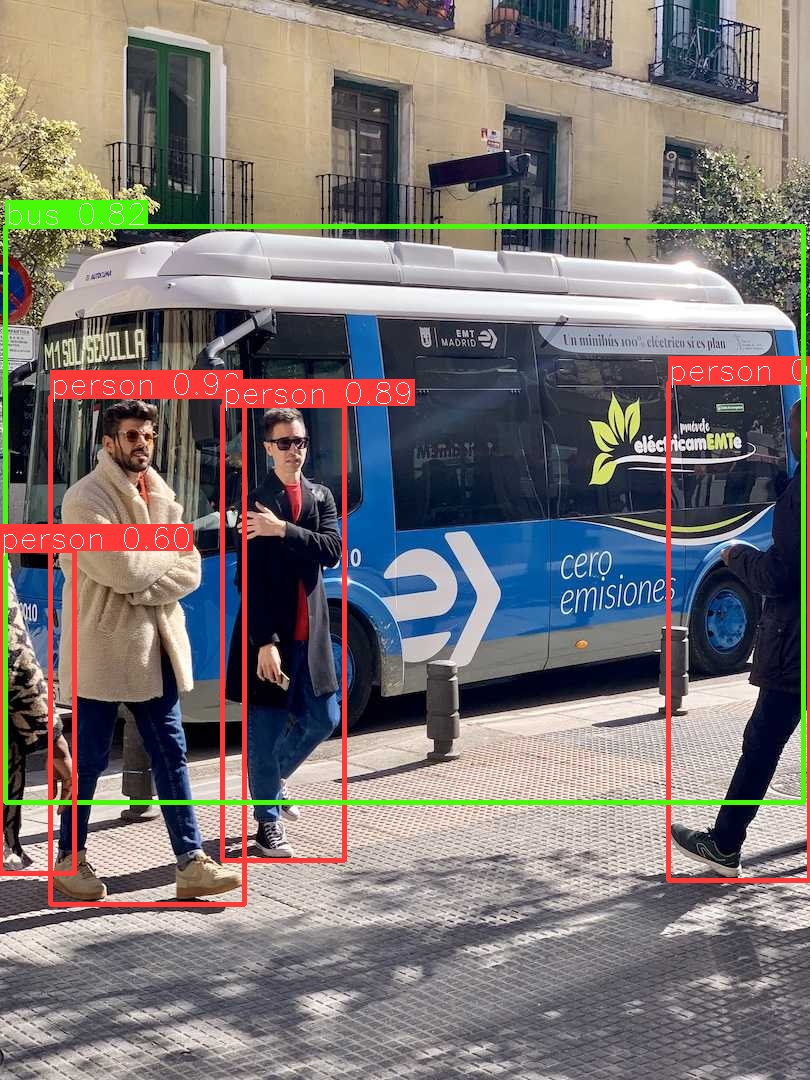

In [5]:
try:
    from IPython.display import Image, display
except ImportError:
    Image = None
    display = None

annotated_path = outputs_dir / "bus_result.jpg"
result.save(str(annotated_path))
print(f"Saved annotated image to: {annotated_path}")

if Image is not None and display is not None:
    display(Image(filename=str(annotated_path)))
else:
    print("Install IPython or open the saved file to view the annotated image.")

# Other task that the models can perform
In the following code snippets, various tasks that the models can perform are presented:
1) Segmentation
2) Dense semantic segmentation

**Segmentation** 
For instance segmentation we follow this steps: 
* Download a test image
* Run a segmentation instance
* Inspect and save results


In [18]:
image_url = "http://images.cocodataset.org/val2017/000000000139.jpg"
image_path = outputs_dir / "room.jpg"

if not image_path.exists():
    print(f"Downloading {image_url}")
    urlretrieve(image_url, image_path)

print(f"Image ready: {image_path}")

Image ready: /home/vaelsys/testNitid/nitid/tutorial/outputs/room.jpg


In [19]:
# For instance segmentation, select the task when constructing the model:
segment_model = NITID("model1s", task="segment")
result = segment_model.predict(str(image_path), conf=0.5)[0]

boxes = result.boxes.xyxy
masks = result.masks.data  # uint8 [N, H, W]
polygons = result.masks.xyn  # normalized polygons

print(result)
print("Boxes:", len(boxes))
print("Mask:", len(masks))
print("Polygons:", len(polygons))

dfine_seg_s_coco_wrapped.pth already exists. Use force=true to overwrite.
[D-FINE] Loaded 'dfine_seg_s_coco_wrapped.pth' — 11.9M params on cpu
Results(path='/home/vaelsys/testNitid/nitid/tutorial/outputs/room.jpg', detections=7, masks=7)
Boxes: 7
Mask: 7
Polygons: 7


Saved annotated image to: /home/vaelsys/testNitid/nitid/tutorial/outputs/room_result.jpg


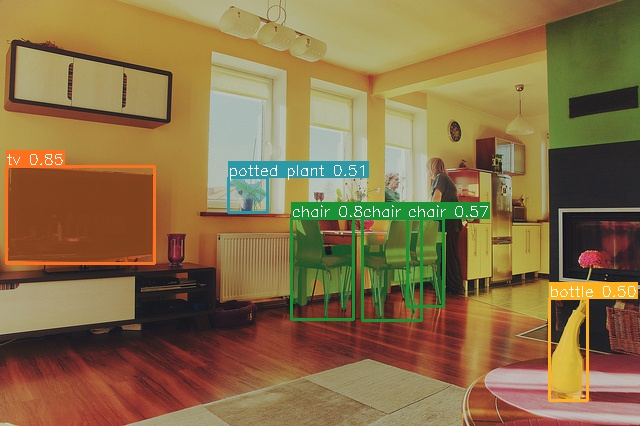

In [20]:
annotated_path = outputs_dir / "room_result.jpg"
result.save(str(annotated_path))
print(f"Saved annotated image to: {annotated_path}")

if Image is not None and display is not None:
    display(Image(filename=str(annotated_path)))
else:
    print("Install IPython or open the saved file to view the annotated image.")

**Dense Semantic segmentation**

For dense semantic segmentation, read the original-resolution class map from result.semantic.mask:
* Download a test image
* Run a segmentation instance
* Inspect and save results

In [28]:
image_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
image_path = outputs_dir / "Lena.jpg"

if not image_path.exists():
    print(f"Downloading {image_url}")
    urlretrieve(image_url, image_path)

print(f"Image ready: {image_path}")

Image ready: /home/vaelsys/testNitid/nitid/tutorial/outputs/Lena.jpg


In [29]:
semantic = NITID("model1s", task="semantic")
result = semantic.predict(str(image_path), save=True, return_probs=True)[0]

class_map = result.semantic.mask  # int64 [H, W]
probabilities = result.semantic.probs  # float [C, H, W]

print(result)
print("Class Map:", len(class_map))
print(class_map)
print("Probabilities:", len(probabilities))

dfine_semantic_s_coco_init_wrapped.pth already exists. Use force=true to overwrite.
[D-FINE] Loaded 'dfine_semantic_s_coco_init_wrapped.pth' — 8.0M params on cpu
Results(path='/home/vaelsys/testNitid/nitid/tutorial/outputs/Lena.jpg', semantic_shape=(512, 512))
Class Map: 512
tensor([[60, 60, 60,  ..., 35, 35, 35],
        [60, 60, 60,  ..., 35, 35, 35],
        [60, 60, 60,  ..., 17, 24, 24],
        ...,
        [61, 61,  0,  ..., 60, 60, 60],
        [61, 61, 61,  ..., 60, 60, 60],
        [61, 61, 61,  ..., 60, 60, 60]])
Probabilities: 80


The image you see is the ID map saved as is: each pixel is worth the class number (0, 1, 2...), and with 26 classes those values ​​are almost black in an 8-bit image

Saved annotated image to: /home/vaelsys/testNitid/nitid/tutorial/outputs/lena_result.jpg


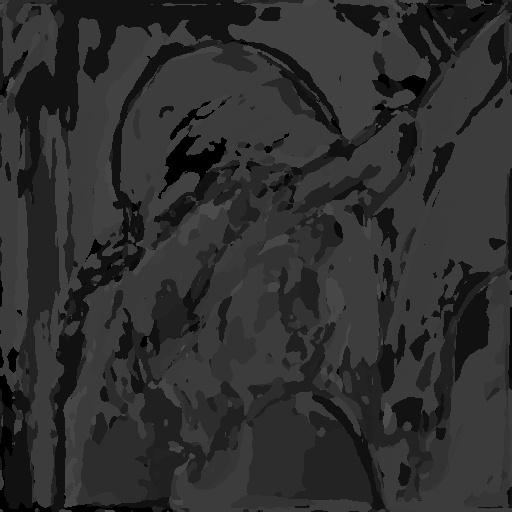

In [31]:
annotated_path = outputs_dir / "lena_result.jpg"
result.save_semantic(str(annotated_path))
print(f"Saved annotated image to: {annotated_path}")

if Image is not None and display is not None:
    display(Image(filename=str(annotated_path)))
else:
    print("Install IPython or open the saved file to view the annotated image.")

To see it in color, apply a palette over

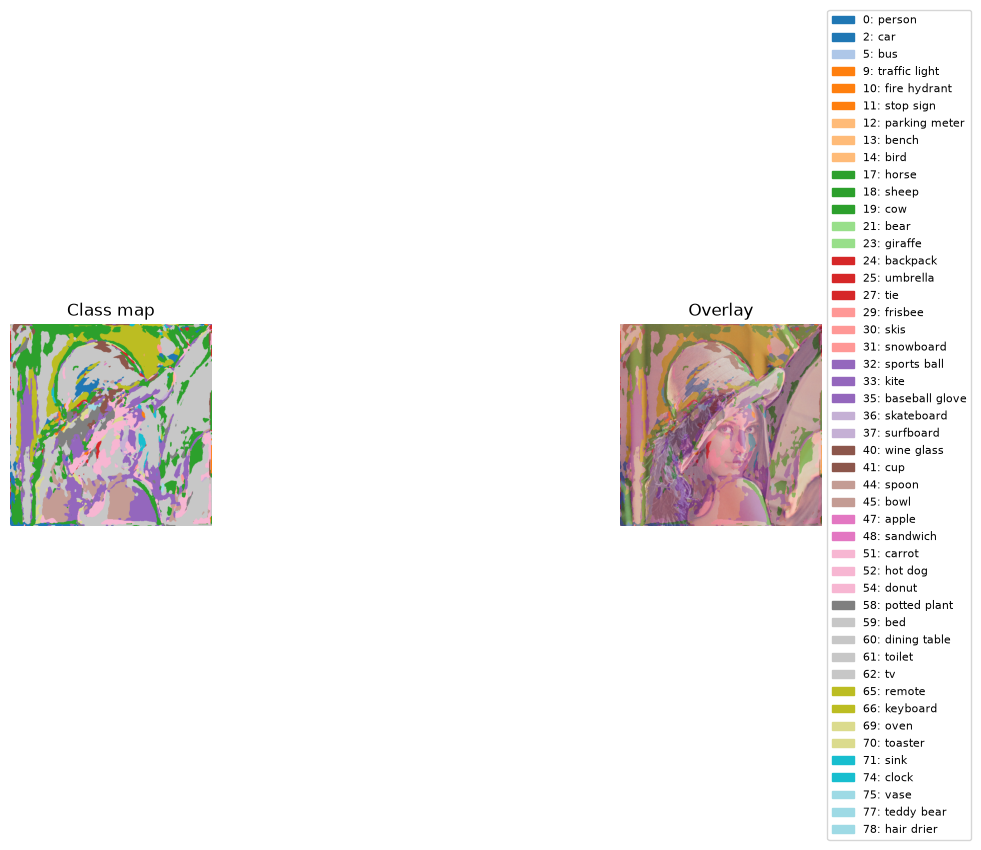

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from PIL import Image

# Palette with a different color for each class
num_classes = int(class_map.max()) + 1
cmap = plt.get_cmap("tab20", max(num_classes, 20))
colors = (cmap(np.arange(num_classes))[:, :3] * 255).astype(np.uint8)
color_mask = colors[class_map]  # [H, W, 3]

# Original image + superimposed mask
image = np.array(Image.open(str(image_path)).convert("RGB").resize(class_map.shape[::-1]))
overlay = (0.5 * image + 0.5 * color_mask).astype(np.uint8)

# Legend only with the classes present
ids = np.unique(class_map)
names = getattr(result, "names", None) or {}
handles = [Patch(color=colors[i] / 255, label=f"{i}: {names.get(i, '')}".strip(": ")) for i in ids]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(color_mask)
axes[0].set_title("Class map")
axes[1].imshow(overlay)
axes[1].set_title("Overlay")
for ax in axes:
    ax.axis("off")
axes[1].legend(handles=handles, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

# Save the PNG in color
Image.fromarray(color_mask).save(outputs_dir / "lena_class_ids_color.png")

If you just want to quickly see the PNG of IDs you already generated, simply scale the values:

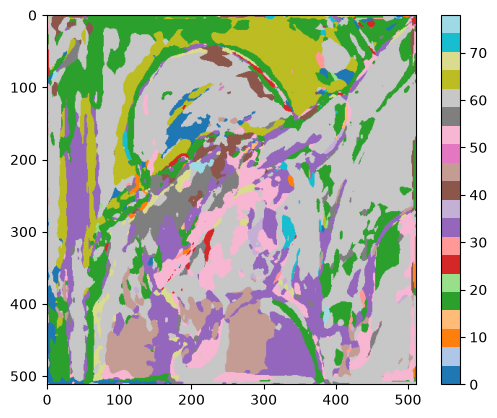

In [35]:
plt.imshow(class_map, cmap="tab20")
plt.colorbar()
plt.show()